# FlashEats — Class 5 Investigation
**Mission:** assemble trustworthy evidence about late deliveries.

Rules: no ML for first 90 minutes; preserve raw API responses; state your definition of late; never silently drop failures.

In [1]:
import json, math, sqlite3, subprocess, sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)


# The notebook runs from exercises/, the classroom pack sits next to it
BASE = Path("FlashEats_Classroom_Pack_V2")
DB_PATH = BASE / "database" / "flasheats.db"

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DB_PATH}. Run this notebook from the folder that contains FlashEats_Classroom_Pack_V2."
    )
print("BASE:", BASE)
print("Database found:", DB_PATH.exists())

BASE: FlashEats_Classroom_Pack_V2
Database found: True


## Challenge 1 — How large is the late-delivery problem?
Write down your definition of late, denominator, cancellation policy, and missing-timestamp policy before querying.

**My definitions (before running anything)**

- Late: delivered and `actual_delivery_at` > `promised_eta` (delay > 0 min). I'll also check > 10 min since Support uses that.
- Denominator: unique delivered orders with an `actual_delivery_at`. Status compared in lowercase so "Delivered" counts.
- Cancelled: excluded, they can't be late or on time. I report the count.
- Missing delivery time: excluded from the rate but counted. No guessing.
- Grain: I expect 1 row = 1 order, checked first.

In [2]:
con=sqlite3.connect(BASE/'database'/'flasheats.db')
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'",con)

,name
0,customers
1,drivers
2,restaurants
3,orders


In [3]:
# Is one row really one order?
display(pd.read_sql("""
SELECT COUNT(*) AS total_rows,
       COUNT(DISTINCT order_id) AS unique_orders,
       COUNT(*) - COUNT(DISTINCT order_id) AS extra_rows
FROM orders
""", con))

# the duplicated order_ids, side by side
dupes = pd.read_sql("""
SELECT rowid AS row_no, o.*
FROM orders o
WHERE order_id IN (SELECT order_id FROM orders GROUP BY order_id HAVING COUNT(*) > 1)
ORDER BY order_id, rowid
""", con)
display(dupes)

# status values as stored, and how many have no delivery time
display(pd.read_sql("""
SELECT final_status,
       COUNT(*) AS n_rows,
       SUM(actual_delivery_at IS NULL) AS missing_delivery_time
FROM orders
GROUP BY final_status
""", con))

,total_rows,unique_orders,extra_rows
0,1603,1600,3


,row_no,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,120,O00120,C0501,R040,D045,Bengaluru,2026-08-13T18:15:00,2026-08-13T19:40:24,2026-08-13T18:29:08.055622,2026-08-13T19:34:08.431508,delivered,18.00,severe,clear
1,1601,O00120,C0501,R040,D045,Bengaluru,2026-08-13T18:15:00,2026-08-13T19:40:24,2026-08-13T18:29:08.055622,2026-08-13T19:34:08.431508,delivered,18.00,medium,clear
2,723,O00723,C0467,R028,D068,Bengaluru,2026-08-05T21:04:00,2026-08-05T22:19:36,2026-08-05T21:15:24.433874,2026-08-05T22:04:30.928322,delivered,18.00,medium,clear
3,1602,O00723,C0467,R028,D068,Bengaluru,2026-08-05T21:04:00,2026-08-05T22:19:36,2026-08-05T21:15:24.433874,2026-08-05T22:04:30.928322,delivered,18.00,high,clear
4,1302,O01302,C0116,R010,D088,Bengaluru,2026-08-26T21:07:00,2026-08-26T22:15:50.273095,2026-08-26T21:35:26.474087,2026-08-26T22:20:27.428561,delivered,14.78,medium,clear
5,1603,O01302,C0116,R010,D088,Bengaluru,2026-08-26T21:07:00,2026-08-26T22:15:50.273095,2026-08-26T21:35:26.474087,2026-08-26T22:20:27.428561,delivered,14.78,high,clear


,final_status,n_rows,missing_delivery_time
0,Delivered,5,0
1,cancelled,68,68
2,delivered,1530,37


In [4]:
# one row per order (first row wins), status + traffic lowercased, times in minutes
BASE_CTE = """
WITH dedup AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY rowid) AS rn
    FROM orders
),
base AS (
    SELECT order_id, customer_id, restaurant_id, driver_id,
           LOWER(TRIM(final_status))   AS status,
           LOWER(TRIM(traffic_bucket)) AS traffic,
           weather_bucket              AS weather,
           distance_km_estimate        AS distance_km,
           created_at, promised_eta, pickup_at, actual_delivery_at,
           (julianday(actual_delivery_at) - julianday(promised_eta)) * 1440 AS delay_min,
           (julianday(promised_eta) - julianday(created_at)) * 1440        AS promised_window_min,
           (julianday(pickup_at) - julianday(created_at)) * 1440           AS order_to_pickup_min,
           (julianday(actual_delivery_at) - julianday(pickup_at)) * 1440   AS pickup_to_door_min
    FROM dedup
    WHERE rn = 1
)
"""

size = pd.read_sql(BASE_CTE + """
SELECT COUNT(*)                                                   AS unique_orders,
       SUM(status = 'cancelled')                                  AS cancelled,
       SUM(status = 'delivered')                                  AS delivered,
       SUM(status = 'delivered' AND actual_delivery_at IS NULL)   AS delivered_no_time,
       SUM(status = 'delivered' AND actual_delivery_at IS NOT NULL) AS valid_delivered,
       SUM(status = 'delivered' AND delay_min > 0)                AS late_any,
       ROUND(100.0 * SUM(status = 'delivered' AND delay_min > 0)
             / SUM(status = 'delivered' AND actual_delivery_at IS NOT NULL), 2) AS late_pct_any,
       SUM(status = 'delivered' AND delay_min > 10)               AS late_over_10,
       ROUND(100.0 * SUM(status = 'delivered' AND delay_min > 10)
             / SUM(status = 'delivered' AND actual_delivery_at IS NOT NULL), 2) AS late_pct_over_10
FROM base
""", con)
display(size)

delivered = pd.read_sql(BASE_CTE + """
SELECT * FROM base
WHERE status = 'delivered' AND actual_delivery_at IS NOT NULL
""", con)
late_only = delivered[delivered["delay_min"] > 0]
print("valid delivered orders:", len(delivered))
print("median lateness among late orders (min):", round(late_only["delay_min"].median(), 2))
print("mean lateness among late orders (min):", round(late_only["delay_min"].mean(), 2))
print("median delay over all valid delivered orders (min):", round(delivered["delay_min"].median(), 2))

,unique_orders,cancelled,delivered,delivered_no_time,valid_delivered,late_any,late_pct_any,late_over_10,late_pct_over_10
0,1600,68,1532,37,1495,843,56.39,349,23.34


valid delivered orders: 1495
median lateness among late orders (min): 8.03
mean lateness among late orders (min): 10.52
median delay over all valid delivered orders (min): 1.41


In [5]:
# worst 10 delays, with chronology flags next to them
worst = pd.read_sql(BASE_CTE + """
SELECT order_id, created_at, promised_eta, pickup_at, actual_delivery_at,
       ROUND(delay_min, 1) AS delay_min, traffic, weather,
       CASE WHEN julianday(promised_eta) < julianday(created_at) THEN 1 ELSE 0 END AS eta_before_created,
       CASE WHEN julianday(actual_delivery_at) < julianday(pickup_at) THEN 1 ELSE 0 END AS delivered_before_pickup
FROM base
WHERE status = 'delivered' AND actual_delivery_at IS NOT NULL
ORDER BY delay_min DESC
LIMIT 10
""", con)
display(worst)

# data-quality checks that can move the number
display(pd.read_sql(BASE_CTE + """
SELECT SUM(julianday(promised_eta) < julianday(created_at))       AS eta_before_created,
       SUM(julianday(actual_delivery_at) < julianday(pickup_at))  AS delivered_before_pickup,
       SUM(status = 'cancelled' AND pickup_at IS NOT NULL)        AS cancelled_with_pickup_time,
       SUM(restaurant_id IS NULL)                                 AS missing_restaurant,
       SUM(driver_id IS NULL)                                     AS missing_driver,
       SUM(distance_km = 18.0)                                    AS distance_exactly_18km
FROM base
""", con))

,order_id,created_at,promised_eta,pickup_at,actual_delivery_at,delay_min,traffic,weather,eta_before_created,delivered_before_pickup
0,O00104,2026-08-09T22:19:00,2026-08-09T22:09:00,2026-08-09T22:47:33.934776,2026-08-09T23:36:20.740161,87.3,medium,clear,1,0
1,O00102,2026-08-11T16:41:00,2026-08-11T16:31:00,2026-08-11T17:05:05.809584,2026-08-11T17:57:17.661772,86.3,medium,clear,1,0
2,O00101,2026-08-24T20:59:00,2026-08-24T20:49:00,2026-08-24T21:25:03.983984,2026-08-24T22:14:30.685278,85.5,low,rain,1,0
3,O00103,2026-08-22T20:11:00,2026-08-22T20:01:00,2026-08-22T20:39:45.064627,2026-08-22T21:10:17.342305,69.3,high,clear,1,0
4,O01081,2026-08-13T17:14:00,2026-08-13T18:15:46.613098,2026-08-13T18:19:53.467196,2026-08-13T19:06:02.677891,50.3,high,clear,0,0
5,O00473,2026-08-14T18:58:00,2026-08-14T20:17:48,2026-08-14T20:05:22.631148,2026-08-14T21:04:00.769224,46.2,high,clear,0,0
6,O01102,2026-08-12T18:25:00,2026-08-12T19:31:12.651822,2026-08-12T19:31:48.324377,2026-08-12T20:16:09.835907,45.0,medium,clear,0,0
7,O00194,2026-08-11T17:36:00,2026-08-11T19:01:48,2026-08-11T18:31:39.836812,2026-08-11T19:40:08.111510,38.3,high,heavy_rain,0,0
8,O01312,2026-08-14T19:02:00,2026-08-14T20:17:36,2026-08-14T20:03:23.614086,2026-08-14T20:54:36.321890,37.0,medium,clear,0,0
9,O00460,2026-08-12T16:27:00,2026-08-12T17:52:24,2026-08-12T17:21:45.188189,2026-08-12T18:29:16.970368,36.9,severe,clear,0,0


,eta_before_created,delivered_before_pickup,cancelled_with_pickup_time,missing_restaurant,missing_driver,distance_exactly_18km
0,4,5,68,3,3,806


In [6]:
# same data, different choices -> how much does the late % move?
sens = pd.read_sql(BASE_CTE + """
SELECT 'A. any delay > 0, valid delivered (my definition)' AS scenario,
       SUM(delay_min > 0) AS late, COUNT(*) AS denominator
FROM base WHERE status = 'delivered' AND actual_delivery_at IS NOT NULL
UNION ALL
SELECT 'B. delay > 10 min', SUM(delay_min > 10), COUNT(*)
FROM base WHERE status = 'delivered' AND actual_delivery_at IS NOT NULL
UNION ALL
SELECT 'C. missing delivery time counted as late', SUM(delay_min > 0 OR actual_delivery_at IS NULL), COUNT(*)
FROM base WHERE status = 'delivered'
UNION ALL
SELECT 'D. all 1600 orders as denominator', SUM(delay_min > 0), COUNT(*)
FROM base
""", con)
sens["late_pct"] = (100 * sens["late"] / sens["denominator"]).round(2)
display(sens)

,scenario,late,denominator,late_pct
0,"A. any delay > 0, valid delivered (my definition)",843,1495,56.39
1,B. delay > 10 min,349,1495,23.34
2,C. missing delivery time counted as late,880,1532,57.44
3,D. all 1600 orders as denominator,843,1600,52.69


- `orders` has 1603 rows but 1600 unique order_ids. The 3 extra rows (O00120, O00723, O01302) differ only in `traffic_bucket`, so I kept the first row and flagged them.
- 1532 delivered (5 stored as "Delivered"), 68 cancelled, 37 delivered with no `actual_delivery_at`. That leaves **1495** valid delivered orders.
- Late (> 0 min): **843 / 1495 = 56.39%**. Over 10 min: 349 = 23.34%.
- Median lateness of late orders: **8.03 min** (mean 10.52).
- The 4 worst "delays" (69.3 to 87.3 min) all have `promised_eta` before `created_at`, so I think they're data errors. First believable one is O01081 at 50.3 min.

Issues that move the number: the threshold (56.39% vs 23.34%), the denominator (52.69% over all 1600 orders), and the 37 missing times (57.44% if they were all late). Also 5 orders are delivered before pickup, 68 cancelled orders have a `pickup_at`, and 806 orders sit at exactly 18.0 km.

### Checkpoint
Compare counts with another team. If they differ, investigate row grain, duplicates, cancellations, missing timestamps, and definitions.

If another team's number is different, my first guesses: they used > 10 min (23.34%), divided by all 1600 orders (52.69%), or counted the missing delivery times as late (57.44%). Not deduping only moves it a little. We should agree on the definition before comparing.

## Challenge 2 — Operations says traffic is the cause
Test the claim. Treat traffic/weather/distance as descriptive signals, not causal proof.

In [7]:
VALID = "WHERE status = 'delivered' AND actual_delivery_at IS NOT NULL"

by_traffic = pd.read_sql(BASE_CTE + f"""
SELECT traffic, COUNT(*) AS orders,
       ROUND(100.0 * AVG(delay_min > 0), 1)  AS late_pct,
       ROUND(100.0 * AVG(delay_min > 10), 1) AS late10_pct,
       ROUND(AVG(delay_min), 1)              AS avg_delay_min,
       ROUND(AVG(promised_window_min), 1)    AS avg_promised_min,
       ROUND(AVG(order_to_pickup_min), 1)    AS avg_order_to_pickup,
       ROUND(AVG(pickup_to_door_min), 1)     AS avg_pickup_to_door,
       ROUND(100.0 * SUM(delay_min > 0 AND weather = 'clear') / SUM(weather = 'clear'), 1) AS late_pct_clear_weather_only
FROM base {VALID}
GROUP BY traffic
ORDER BY late_pct DESC
""", con)
display(by_traffic)

by_weather = pd.read_sql(BASE_CTE + f"""
SELECT weather, COUNT(*) AS orders,
       ROUND(100.0 * AVG(delay_min > 0), 1) AS late_pct,
       ROUND(AVG(delay_min), 1)             AS avg_delay_min,
       ROUND(AVG(pickup_to_door_min), 1)    AS avg_pickup_to_door
FROM base {VALID}
GROUP BY weather
ORDER BY late_pct DESC
""", con)
display(by_weather)

by_distance = pd.read_sql(BASE_CTE + f"""
SELECT CASE WHEN distance_km = 18.0 THEN 'exactly 18.0 (default?)'
            WHEN distance_km < 5  THEN '1: < 5 km'
            WHEN distance_km < 10 THEN '2: 5-10 km'
            WHEN distance_km < 18 THEN '3: 10-18 km'
            ELSE '4: > 18 km' END AS distance_bucket,
       COUNT(*) AS orders,
       ROUND(100.0 * AVG(delay_min > 0), 1) AS late_pct,
       ROUND(AVG(delay_min), 1)             AS avg_delay_min,
       ROUND(AVG(promised_window_min), 1)   AS avg_promised_min
FROM base {VALID}
GROUP BY distance_bucket
ORDER BY distance_bucket
""", con)
display(by_distance)

,traffic,orders,late_pct,late10_pct,avg_delay_min,avg_promised_min,avg_order_to_pickup,avg_pickup_to_door,late_pct_clear_weather_only
0,high,424,66.5,29.2,5.3,72.9,28.7,49.5,64.2
1,severe,123,65.9,32.5,6.3,79.9,27.8,58.4,60.0
2,medium,588,51.4,20.9,2.1,68.6,27.1,43.6,47.9
3,low,360,49.4,17.2,1.2,66.2,27.4,40.0,47.5


,weather,orders,late_pct,avg_delay_min,avg_pickup_to_door
0,heavy_rain,72,73.6,7.7,57.7
1,rain,231,67.1,6.5,50.7
2,clear,1192,53.3,2.2,43.9


,distance_bucket,orders,late_pct,avg_delay_min,avg_promised_min
0,1: < 5 km,69,53.6,1.4,45.9
1,2: 5-10 km,222,55.9,2.6,56.0
2,3: 10-18 km,452,56.2,3.2,68.8
3,4: > 18 km,3,100.0,25.1,80.2
4,exactly 18.0 (default?),749,56.7,3.3,77.4


,order_to_pickup,orders,late_pct,avg_delay_min
0,1: < 20 min,345,2.3,-8.7
1,2: 20-30 min,632,51.6,0.6
2,3: 30-40 min,330,98.2,9.8
3,4: 40+ min,188,98.4,21.6


Correlation of delay_min with each part of the order (valid delivered orders):
order_to_pickup_min    0.832
pickup_to_door_min     0.215
promised_window_min   -0.023
distance_km            0.066
dtype: float64


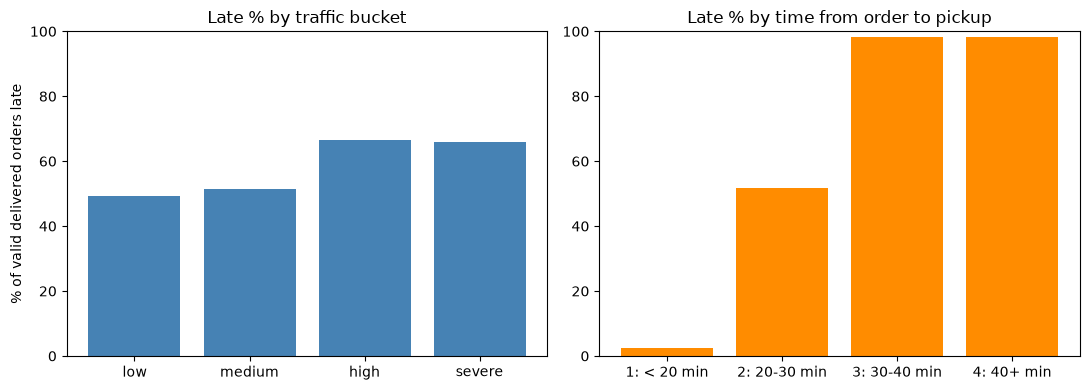

In [8]:
# where does the delay sit? before pickup or after pickup?
by_pickup_wait = pd.read_sql(BASE_CTE + f"""
SELECT CASE WHEN order_to_pickup_min < 20 THEN '1: < 20 min'
            WHEN order_to_pickup_min < 30 THEN '2: 20-30 min'
            WHEN order_to_pickup_min < 40 THEN '3: 30-40 min'
            ELSE '4: 40+ min' END AS order_to_pickup,
       COUNT(*) AS orders,
       ROUND(100.0 * AVG(delay_min > 0), 1) AS late_pct,
       ROUND(AVG(delay_min), 1)             AS avg_delay_min
FROM base {VALID}
GROUP BY order_to_pickup
ORDER BY order_to_pickup
""", con)
display(by_pickup_wait)

print("Correlation of delay_min with each part of the order (valid delivered orders):")
print(delivered[["order_to_pickup_min", "pickup_to_door_min", "promised_window_min", "distance_km"]]
      .corrwith(delivered["delay_min"]).round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
t = by_traffic.set_index("traffic").loc[["low", "medium", "high", "severe"]]
axes[0].bar(t.index, t["late_pct"], color="steelblue")
axes[0].set_title("Late % by traffic bucket")
axes[0].set_ylabel("% of valid delivered orders late")
p = by_pickup_wait.set_index("order_to_pickup")
axes[1].bar(p.index, p["late_pct"], color="darkorange")
axes[1].set_title("Late % by time from order to pickup")
for ax in axes:
    ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

- Traffic is associated with lateness: high 66.5% and severe 65.9% late vs low 49.4%. The gap holds in clear weather only (64.2% vs 47.5%).
- Rain too: heavy_rain 73.6%, clear 53.3%.
- Distance is flat (53.6% to 56.7%), and 749 valid orders have exactly 18.0 km anyway.
- Time from order to pickup is the big one: under 20 min only 2.3% late, 30-40 min 98.2%. Correlation with delay 0.832, vs 0.215 for the ride.
- Order-to-pickup is about the same in every traffic bucket (27.1 to 28.7 min). Traffic mainly lengthens the ride (40.0 vs 58.4 min), and the promise already stretches for it (66.2 vs 79.9 min).

Hypothesis: most delay builds up before pickup, and traffic adds a bit during the ride.

Can't rule out: the pickup wait mixes kitchen time and driver arrival, and busy hours could drive both. This is all association, not causation.

## Challenge 3 — Customer Support disagrees
Inspect support tickets. What are customers actually complaining about? Are ticket records unique?

In [9]:
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
display(tickets.head())
print("rows:", len(tickets), "| unique ticket_id:", tickets["ticket_id"].nunique())
print("duplicate ticket_id rows:", tickets["ticket_id"].duplicated().sum(),
      "| fully identical rows:", tickets.duplicated().sum())
print("tickets with no order_id:", tickets["order_id"].isna().sum())
display(tickets[tickets["ticket_id"].duplicated(keep=False)])

# raw category values - repr() shows trailing spaces
print(tickets["category"].map(repr).value_counts())

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


rows: 202 | unique ticket_id: 201
duplicate ticket_id rows: 1 | fully identical rows: 1
tickets with no order_id: 3


,ticket_id,order_id,created_at,category,customer_message
12,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.
201,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.


category
'late_delivery'        38
'eta_changed'          37
'restaurant_delay'     37
'ready_but_waiting'    33
'status_mismatch'      29
'driver_not_moving'    25
'Late Delivery'         1
'late_delivery '        1
'ETA issue'             1
Name: count, dtype: int64


In [10]:
tk = tickets.drop_duplicates().copy()   # 1 exact duplicate row removed
# only fix case/spaces; 'ETA issue' stays its own value (it may or may not mean eta_changed)
tk["category_norm"] = tk["category"].str.strip().str.lower().str.replace(" ", "_")

# join each ticket to the order's delivery outcome (many tickets -> one order)
order_view = pd.read_sql(BASE_CTE + """
SELECT order_id, status, promised_eta, actual_delivery_at, delay_min,
       CASE WHEN status = 'delivered' AND actual_delivery_at IS NOT NULL
            THEN (delay_min > 0) END AS is_late
FROM base
""", con)
tk = tk.merge(order_view, on="order_id", how="left", validate="many_to_one")
tk["opened_before_promised_eta"] = (
    pd.to_datetime(tk["created_at"], format="mixed") < pd.to_datetime(tk["promised_eta"], format="mixed")
)

summary = (tk.groupby("category_norm")
             .agg(tickets=("ticket_id", "count"),
                  linked_to_order=("order_id", "count"),
                  pct_on_late_orders=("is_late", lambda s: round(100 * s.mean(), 1)),
                  median_delay_min=("delay_min", lambda s: round(s.median(), 1)),
                  pct_opened_before_eta=("opened_before_promised_eta", lambda s: round(100 * s.mean(), 1)))
             .sort_values("tickets", ascending=False))
display(summary)

linked = tk[tk["is_late"].notna()]
print("tickets linked to a valid delivered order:", len(linked))
print("  ...of those on orders the system calls ON TIME:", int((linked["is_late"] == 0).sum()))
handoff = ["restaurant_delay", "ready_but_waiting", "status_mismatch"]
print("restaurant/handoff tickets:", int(tk["category_norm"].isin(handoff).sum()), "of", len(tk), "unique tickets")
print("tickets opened before the stored promised_eta:", int(tk["opened_before_promised_eta"].sum()), "of", tk["order_id"].notna().sum())

,tickets,linked_to_order,pct_on_late_orders,median_delay_min,pct_opened_before_eta
category_norm,,,,,
late_delivery,39,38,86.8,14.8,97.4
eta_changed,37,36,80.0,7.7,94.6
restaurant_delay,37,37,75.7,10.5,94.6
ready_but_waiting,33,33,90.9,12.2,97.0
status_mismatch,29,28,92.9,12.7,93.1
driver_not_moving,25,25,68.0,10.4,96.0
eta_issue,1,1,100.0,5.4,100.0


tickets linked to a valid delivered order: 197
  ...of those on orders the system calls ON TIME: 34
restaurant/handoff tickets: 99 of 201 unique tickets
tickets opened before the stored promised_eta: 192 of 198


- Categories after fixing case/spaces: late_delivery 39, eta_changed 37, restaurant_delay 37, ready_but_waiting 33, status_mismatch 29, driver_not_moving 25, "ETA issue" 1 (left alone, not sure it means eta_changed).
- Ticket IDs aren't unique: T00013 is duplicated. 3 tickets have no order_id.
- 99 of 201 unique tickets are about the restaurant or handoff. Only driver_not_moving (25) is close to a traffic story.
- 34 of 197 tickets on valid deliveries are on orders the system calls on time.
- 192 of 198 linked tickets were opened before the stored `promised_eta`. So customers probably saw a different ETA than the one in `orders`.

| | System view | Customer view |
|---|---|---|
| Problem | 56.39% late, more with traffic | waiting on restaurant/rider, ETA changing |
| "Late" means | after stored promised_eta | after the ETA the app showed |

Tickets show what the customer saw (ETA moving, food ready with no rider). Timestamps can't.

## Challenge 4 — Retrieve Dispatch data reliably

In [11]:
api_proc = subprocess.Popen([sys.executable, str(BASE / "api" / "mock_dispatch_api.py")],
                            stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
time.sleep(2)
requests.get("http://127.0.0.1:8000/health", timeout=10).json()

{'service': 'flasheats-dispatch-api', 'status': 'ok'}

In [12]:
url='http://127.0.0.1:8000/dispatch/orders'
r=requests.get(url,params={'page':1,'page_size':50},timeout=10)
print(r.status_code); payload=r.json(); print(payload.keys(), len(payload.get('data',[])), payload.get('has_more'))

200
dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records']) 50 True


### Your task
Implement pagination + retry + raw-page preservation. Refuse to claim success if ingestion is incomplete.

In [13]:
RAW_DIR = BASE / "student_output" / "raw_dispatch" / "class5_starter"
RAW_DIR.mkdir(parents=True, exist_ok=True)

API_URL = "http://127.0.0.1:8000/dispatch/orders"
PAGE_SIZE = 100
MAX_RETRIES = 4                  # retries per page, after the first try
RETRYABLE = {429, 500, 502, 503, 504}


def get_page(page, retry_log):
    """Get one page, retrying 429/5xx/network errors. Every retry goes into retry_log. Raises if it never succeeds."""
    last_problem = None
    for attempt in range(MAX_RETRIES + 1):
        try:
            r = requests.get(API_URL, params={"page": page, "page_size": PAGE_SIZE}, timeout=10)
        except requests.RequestException as e:
            r, last_problem = None, type(e).__name__
        if r is not None:
            if r.status_code == 200:
                return r
            if r.status_code not in RETRYABLE:
                raise RuntimeError(f"page {page}: HTTP {r.status_code} is not retryable -> {r.text[:200]}")
            last_problem = r.status_code
        if attempt == MAX_RETRIES:
            break
        # use the API's retry_after_seconds (429) if given, else exponential backoff 1s, 2s, 4s...
        wait = 2 ** attempt
        if r is not None:
            try:
                wait = float(r.json().get("retry_after_seconds", wait))
            except ValueError:
                pass
        retry_log.append({"page": page, "attempt": attempt + 1, "problem": last_problem,
                          "response": None if r is None else r.text.strip(), "wait_s": wait})
        print(f"page {page}: got {last_problem} on attempt {attempt + 1}, waiting {wait}s then retrying")
        time.sleep(wait)
    raise RuntimeError(f"page {page}: still failing after {MAX_RETRIES} retries (last: {last_problem}). "
                       "Ingestion is INCOMPLETE - do not use the dispatch data.")


def fetch_all_dispatch_orders():
    for old in RAW_DIR.glob("*.json"):   # only this notebook's folder, so old runs can't fake completeness
        old.unlink()
    records, saved_files, totals, retry_log = [], [], set(), []
    page = 1
    while True:
        r = get_page(page, retry_log)
        payload = r.json()
        # save the raw body exactly as received, before touching it
        path = RAW_DIR / f"dispatch_page_{page:03d}.json"
        path.write_text(r.text)
        saved_files.append(path)
        totals.add(payload["total_records"])
        records.extend(payload["data"])
        if not payload["has_more"]:
            break
        page += 1
        if page > 500:   # guard against an API that never says has_more = False
            raise RuntimeError("more than 500 pages, stopping - something is wrong")
    return records, {"pages": page, "saved_files": saved_files, "total_records_seen": totals, "retry_log": retry_log}

In [14]:
dispatch_records, run_info = fetch_all_dispatch_orders()
print("\npages fetched:", run_info["pages"], "| records retrieved:", len(dispatch_records))
print("\nRetry events:")
display(pd.DataFrame(run_info["retry_log"]))

page 3: got 500 on attempt 1, waiting 1.0s then retrying


page 5: got 429 on attempt 1, waiting 1.0s then retrying



pages fetched: 16 | records retrieved: 1600

Retry events:


,page,attempt,problem,response,wait_s
0,3,1,500,"{""error"":""temporary upstream failure"",""retryable"":true}",1.0
1,5,1,429,"{""error"":""rate limit exceeded"",""retry_after_seconds"":1}",1.0


In [15]:
dispatch = pd.DataFrame(dispatch_records)
total = run_info["total_records_seen"]
expected_pages = math.ceil(next(iter(total)) / PAGE_SIZE)
saved_counts = sum(len(json.loads(p.read_text())["data"]) for p in run_info["saved_files"])

checks = {
    "API reported the same total_records on every page": len(total) == 1,
    "records retrieved == total_records": len(dispatch) == next(iter(total)),
    "order_id is unique in the retrieved data": dispatch["order_id"].is_unique,
    "pages fetched == ceil(total / page_size)": run_info["pages"] == expected_pages,
    "every page saved to disk (and nothing else in the folder)": all(p.exists() for p in run_info["saved_files"])
        and len(list(RAW_DIR.glob("*.json"))) == expected_pages,
    "records in saved raw files == records retrieved": saved_counts == len(dispatch),
}
for name, ok in checks.items():
    print("PASS" if ok else "FAIL", "-", name)
print("total_records:", total, "| retrieved:", len(dispatch), "| raw files:", len(run_info["saved_files"]),
      "| records in raw files:", saved_counts)

if not all(checks.values()):
    raise RuntimeError("Dispatch ingestion is incomplete, stopping here.")
print("\nIngestion complete.")
print(sorted(p.name for p in RAW_DIR.glob("dispatch_page_*.json"))[:3], "...")

PASS - API reported the same total_records on every page
PASS - records retrieved == total_records
PASS - order_id is unique in the retrieved data
PASS - pages fetched == ceil(total / page_size)
PASS - every page saved to disk (and nothing else in the folder)
PASS - records in saved raw files == records retrieved
total_records: {1600} | retrieved: 1600 | raw files: 16 | records in raw files: 1600

Ingestion complete.
['dispatch_page_001.json', 'dispatch_page_002.json', 'dispatch_page_003.json'] ...


In [16]:
# reconcile against the orders table (deduped)
orders_u = pd.read_sql(BASE_CTE + "SELECT order_id, status, driver_id FROM base", con)
missing_in_dispatch = set(orders_u["order_id"]) - set(dispatch["order_id"])
extra_in_dispatch = set(dispatch["order_id"]) - set(orders_u["order_id"])
print("orders not in dispatch:", len(missing_in_dispatch), "| dispatch orders not in orders table:", len(extra_in_dispatch))

rec = orders_u.merge(dispatch, on="order_id", how="inner", suffixes=("_orders", "_dispatch"), validate="one_to_one")
print("joined rows:", len(rec))
display(pd.crosstab(rec["status"], rec["dispatch_status"]))

diff_driver = rec[rec["driver_id_orders"] != rec["driver_id_dispatch"]]
print("orders where driver differs:", len(diff_driver))
print("  of those, reassigned in dispatch:", diff_driver["reassigned_at"].notna().sum())
print("  of those, driver missing in orders table:", diff_driver["driver_id_orders"].isna().sum())
print("  orders table driver == dispatch original_driver_id (when not null):",
      (rec["driver_id_orders"].dropna() == rec.loc[rec["driver_id_orders"].notna(), "original_driver_id"]).all())

orders not in dispatch: 0 | dispatch orders not in orders table: 0
joined rows: 1600


dispatch_status,cancelled,completed
status,,
cancelled,68,0
delivered,0,1532


orders where driver differs: 98
  of those, reassigned in dispatch: 95
  of those, driver missing in orders table: 3
  orders table driver == dispatch original_driver_id (when not null): True


- 16 pages of 100. Page 3 gave HTTP 500 and page 5 gave 429 on the first try; both worked after a 1.0 s wait (the 429 used `retry_after_seconds`).
- 1600 records = `total_records`, order_ids unique, 16 raw pages saved in `student_output/raw_dispatch/class5_starter/` and they add up to 1600.
- Matches `orders` both ways. Dispatch completed/cancelled = 1532 / 68.
- 98 orders have a different driver: 95 reassigned, 3 null in `orders`. So `orders.driver_id` is the original driver.
- If a page keeps failing the function raises instead of returning partial data.

## Challenge 5 — Driver events
What is observed vs inferred? Can you find a reliable driver-arrival-at-restaurant event?

In [17]:
with open(BASE / "data" / "driver_events.json") as f:
    driver_events = json.load(f)

flat = [{"driver_id": d["driver_id"], **e} for d in driver_events for e in d["events"]]
ev = pd.DataFrame(flat)
ev["ts"] = pd.to_datetime(ev["timestamp"], format="mixed")
print("drivers:", len(driver_events), "| events:", len(ev), "| orders covered:", ev["order_id"].nunique())
display(ev["type"].value_counts())
print("any explicit arrived-at-restaurant event?", any("arriv" in t for t in ev["type"].unique()))

# events are not stored in time order inside each driver
out_of_order = sum((pd.to_datetime(pd.Series([e["timestamp"] for e in d["events"]])).diff().dt.total_seconds() < 0).sum()
                   for d in driver_events)
print("events listed earlier than the previous event (per driver list):", out_of_order)

m = ev[ev["type"] != "gps_ping"].pivot_table(index="order_id", columns="type", values="ts", aggfunc="first")
print("orders with picked_up before assigned:", int((m["picked_up"] < m["assigned"]).sum()))

# which driver id do the events use? compare with dispatch (current) and orders (original)
ev_drv = ev[ev["type"] == "assigned"][["order_id", "driver_id"]].merge(
    dispatch[["order_id", "driver_id", "original_driver_id"]], on="order_id", suffixes=("_events", "_dispatch"))
print("event driver == dispatch current driver:", round(100 * (ev_drv["driver_id_events"] == ev_drv["driver_id_dispatch"]).mean(), 1), "%")
print("event driver == dispatch original driver:", round(100 * (ev_drv["driver_id_events"] == ev_drv["original_driver_id"]).mean(), 1), "%")

drivers: 120 | events: 10035 | orders covered: 1600


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

any explicit arrived-at-restaurant event? False
events listed earlier than the previous event (per driver list): 2314
orders with picked_up before assigned: 14
event driver == dispatch current driver: 100.0 %
event driver == dispatch original driver: 94.1 %


In [18]:
# can GPS tell us when the driver reached the restaurant?
restaurants = pd.read_sql("SELECT restaurant_id, lat AS r_lat, lon AS r_lon FROM restaurants", con)
order_rest = pd.read_sql(BASE_CTE + "SELECT order_id, restaurant_id, promised_eta, pickup_at, actual_delivery_at FROM base", con)
gps = (ev[ev["type"] == "gps_ping"]
       .merge(order_rest, on="order_id", how="left")
       .merge(restaurants, on="restaurant_id", how="left"))

def km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(a))

gps["km_to_restaurant"] = km(gps["lat"], gps["lon"], gps["r_lat"], gps["r_lon"])
bad_coords = ((gps["lat"] < 12.5) | (gps["lat"] > 13.5) | (gps["lon"] < 77.2) | (gps["lon"] > 78.0)).sum()
closest = gps.groupby("order_id")["km_to_restaurant"].min()
gap = ev[ev["type"] == "gps_ping"].sort_values(["order_id", "ts"]).groupby("order_id")["ts"].diff().dt.total_seconds() / 60

print("gps pings:", len(gps), "| pings outside the Bengaluru box:", int(bad_coords))
print("pings per order (median):", ev[ev["type"] == "gps_ping"].groupby("order_id").size().median())
print("median minutes between pings:", round(gap.median(), 1))
print("closest ping to the restaurant, median km:", round(closest.median(), 2))
print("orders with any ping within 0.5 km of the restaurant:", int((closest <= 0.5).sum()), "of", closest.size)
print("gps rows with no restaurant to compare (restaurant_id missing):", int(gps["r_lat"].isna().sum()))

gps pings: 5371 | pings outside the Bengaluru box: 189
pings per order (median): 3.0
median minutes between pings: 13.4
closest ping to the restaurant, median km: 4.16
orders with any ping within 0.5 km of the restaurant: 17 of 1532
gps rows with no restaurant to compare (restaurant_id missing): 10


In [19]:
# driver pickup/delivery vs the orders table
cmp = m.join(order_rest.set_index("order_id")[["promised_eta", "pickup_at", "actual_delivery_at"]])
for c in ["promised_eta", "pickup_at", "actual_delivery_at"]:
    cmp[c] = pd.to_datetime(cmp[c], format="mixed")
both_pickup = cmp.dropna(subset=["picked_up"])
print("orders with a driver picked_up event:", len(both_pickup))
print("  driver pickup == orders.pickup_at:", int((both_pickup["picked_up"] == both_pickup["pickup_at"]).sum()))
print("  orders with pickup_at but no driver pickup event (cancelled):", int(cmp["picked_up"].isna().sum()))
d = cmp.dropna(subset=["delivered"])
print("driver delivered == orders.actual_delivery_at:", int((d["delivered"] == d["actual_delivery_at"]).sum()),
      "| driver has delivered but orders table is null:", int(d["actual_delivery_at"].isna().sum()))

# the 5 orders delivered 'before pickup' in the orders table
bad = cmp[cmp["actual_delivery_at"] < cmp["pickup_at"]]
display(bad[["assigned", "picked_up", "pickup_at", "delivered", "actual_delivery_at"]])
print("orders.pickup_at later than driver pickup by (min):",
      ((bad["pickup_at"] - bad["picked_up"]).dt.total_seconds() / 60).round(1).tolist())

# what if we filled the 37 missing delivery times from driver events? (sensitivity only, not a fix)
fill = cmp[cmp["actual_delivery_at"].isna() & cmp["delivered"].notna()]
fill_late = int(((fill["delivered"] - fill["promised_eta"]).dt.total_seconds() > 0).sum())
base_late, base_n = int((delivered["delay_min"] > 0).sum()), len(delivered)
print(f"backfilled orders: {len(fill)}, of which late: {fill_late}")
print(f"late % with backfill: {100 * (base_late + fill_late) / (base_n + len(fill)):.2f}% "
      f"({base_late + fill_late}/{base_n + len(fill)}) vs {100 * base_late / base_n:.2f}% without")

orders with a driver picked_up event: 1532
  driver pickup == orders.pickup_at: 1527
  orders with pickup_at but no driver pickup event (cancelled): 68
driver delivered == orders.actual_delivery_at: 1495 | driver has delivered but orders table is null: 37


,assigned,picked_up,pickup_at,delivered,actual_delivery_at
order_id,,,,,
O00051,2026-08-01 15:15:10.334213,2026-08-01 15:25:54.609569,2026-08-01 16:24:51.495665,2026-08-01 16:19:51.495665,2026-08-01 16:19:51.495665
O00052,2026-08-24 17:09:27.940686,2026-08-24 17:19:34.353083,2026-08-24 18:16:16.946011,2026-08-24 18:11:16.946011,2026-08-24 18:11:16.946011
O00053,2026-08-13 17:06:45.255349,2026-08-13 17:42:23.641275,2026-08-13 18:25:53.797613,2026-08-13 18:20:53.797613,2026-08-13 18:20:53.797613
O00054,2026-08-28 20:00:49.745255,2026-08-28 20:23:52.944934,2026-08-28 21:25:10.582862,2026-08-28 21:20:10.582862,2026-08-28 21:20:10.582862
O00055,2026-08-16 12:53:41.483545,2026-08-16 13:20:04.394373,2026-08-16 14:08:05.645770,2026-08-16 14:03:05.645770,2026-08-16 14:03:05.645770


orders.pickup_at later than driver pickup by (min): [58.9, 56.7, 43.5, 61.3, 48.0]
backfilled orders: 37, of which late: 24
late % with backfill: 56.59% (867/1532) vs 56.39% without


- No arrived-at-restaurant event. Types are assigned 1600, gps_ping 5371, picked_up 1532, delivered 1532.
- GPS can't replace it: pings are 13.4 min apart, 189 are outside Bengaluru, and the nearest ping is 4.16 km from the restaurant (median). Only 17 of 1532 orders get within 0.5 km.
- Driver `delivered` matches `orders` for all 1495 and fills the 37 gaps (56.59% if used, sensitivity only).

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | Observed | driver_events, dispatch | 14 picked up before assigned |
| Driver at restaurant | Not observed, GPS only | gps_ping | sparse, 189 bad coordinates |
| Picked up | Observed | driver_events, orders | 5 orders off by 43.5 to 61.3 min |
| Delivered | Observed | driver_events, orders | 37 missing in orders |

## Final FDE recommendation
Prepare one slide: problem size, evidence, uncertainty, missing instrumentation, next step.

**Would you build the AI delay predictor now? Why or why not?**

**One slide**
- Problem size: 56.39% of valid delivered orders were late (median 8.03 min), but only 23.34% by more than 10 min.
- Evidence: lateness goes with long order-to-pickup waits (98.2% late at 30-40 min). Traffic and rain are linked too, mostly through the ride.
- Uncertainty: can't split the wait into kitchen vs driver; the stored ETA may not be what customers saw.
- Missing: arrived-at-restaurant and food-ready events, a log of ETAs shown.
- Next: agree the late definition, then add those events.

**AI delay predictor now?** No. The label isn't agreed and the main delay signal can't be explained with the events we have. I'd fix the definition and instrumentation first.

In [20]:
con.close()
api_proc.terminate()
api_proc.wait(timeout=10)
print("DB closed, API stopped (return code", api_proc.returncode, ")")

DB closed, API stopped (return code -15 )
